In [24]:
from pathlib import Path
import xarray as xr
import pandas as pd
from neuralhydrology.evaluation.metrics import (
    mean_peak_timing,
    missed_peaks,
    mean_absolute_percentage_peak_error,
)
import matplotlib.pyplot as plt
from xarray import DataArray

In [25]:
# ------------- Paths -------------
time_series = Path("../../extending_caravan/data/time_series") #US
camels_timeseries = Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #US
basins_file = Path("../basins_without_snow.txt") #US

time_series_uy = Path("../data/time_series") #UY
basins_file_uy = Path("../basins.txt") #UY 

# UY

In [26]:
ds_uy = xr.open_dataset(time_series_uy / "CAMELS_UY_6.nc")
ds_uy

<xarray.Dataset> Size: 498kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_gauge_mm_day   (date) float32 45kB ...
    prcp_mswep_mm_day   (date) float32 45kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge, MSWEP and CHIRPS added where available

In [27]:
with open(basins_file_uy, "r") as f:
    basins_uy = f.read().splitlines()

basins_uy

['CAMELS_UY_2',
 'CAMELS_UY_3',
 'CAMELS_UY_5',
 'CAMELS_UY_6',
 'CAMELS_UY_7',
 'CAMELS_UY_8',
 'CAMELS_UY_9',
 'CAMELS_UY_10',
 'CAMELS_UY_11',
 'CAMELS_UY_15',
 'CAMELS_UY_16']

        peak_timing               missed_peaks                mape_peak  \
               mean median    std         mean median    std       mean   
product                                                                   
caravan       0.485  0.488  0.066        0.620  0.622  0.040  62.275002   
chirps        0.592  0.590  0.045        0.523  0.530  0.050  62.452999   
mswep         0.492  0.494  0.031        0.482  0.483  0.045  57.354000   

                           
            median    std  
product                    
caravan  63.314999  3.553  
chirps   62.830002  3.512  
mswep    57.978001  3.510  


/tmp/ipykernel_7912/3233183594.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS.keys()), patch_artist=True)
/tmp/ipykernel_7912/3233183594.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS.keys()), patch_artist=True)
/tmp/ipykernel_7912/3233183594.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS.keys()), patch_artist=True)


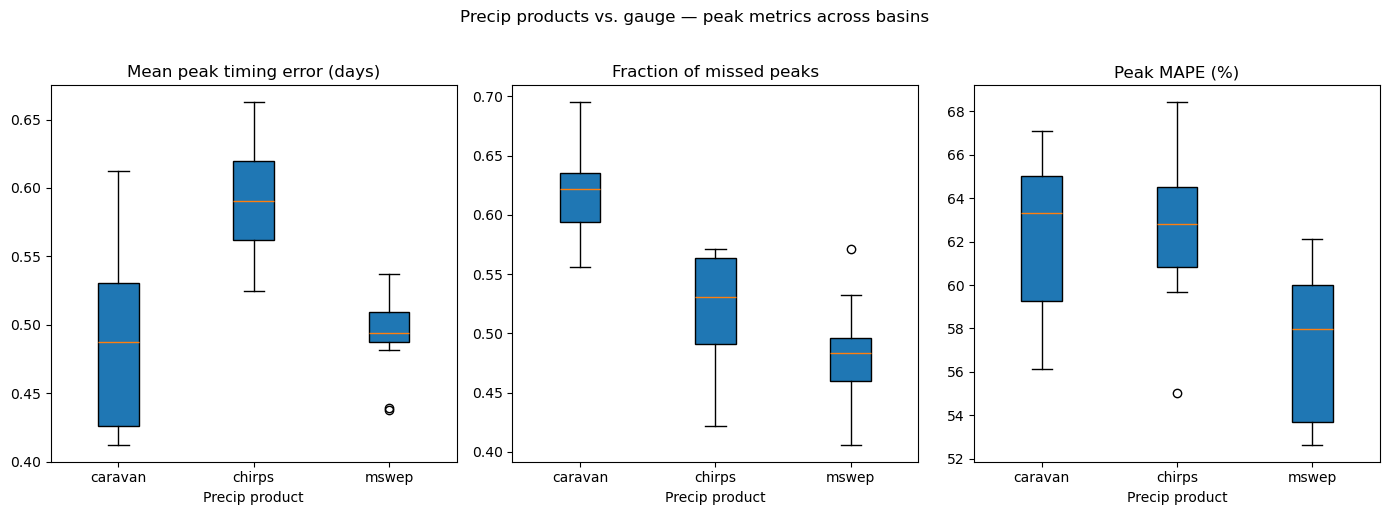

In [43]:
# Precip products to compare against gauge
PRECIP_COLS = {
    "caravan":   "prcp_mm_day",
    "chirps": "prcp_chirps_mm_day",
    "mswep":  "prcp_mswep_mm_day",

}
GAUGE_COL = "prcp_gauge_mm_day"

results = []

for basin_name in basins_uy:
    try:
        ds = xr.open_dataset(time_series_uy / f"{basin_name}.nc")
        vars_to_drop = [v for v in ["basin"] if v in ds]
        if vars_to_drop:
            ds = ds.drop_vars(vars_to_drop)

        if GAUGE_COL not in ds:
            print(f"Skipping {basin_name}: no gauge precip")
            continue

        obs: DataArray = ds[GAUGE_COL]

        for product_name, col in PRECIP_COLS.items():
            if col not in ds:
                continue

            sim: DataArray = ds[col]

            row = {"basin": basin_name, "product": product_name}

            try:
                row["peak_timing"] = mean_peak_timing(
                    obs, sim, resolution="1D", datetime_coord="date"  # <-- key fix
                )
            except Exception as e:
                row["peak_timing"] = np.nan
                print(f"  peak_timing failed ({basin_name}, {product_name}): {e}")

            try:
                row["missed_peaks"] = missed_peaks(
                    obs, sim, resolution="1D", datetime_coord="date"  # <-- key fix
                )
            except Exception as e:
                row["missed_peaks"] = np.nan
                print(f"  missed_peaks failed ({basin_name}, {product_name}): {e}")

            try:
                row["mape_peak"] = mean_absolute_percentage_peak_error(obs, sim)
            except Exception as e:
                row["mape_peak"] = np.nan
                print(f"  mape_peak failed ({basin_name}, {product_name}): {e}")

            results.append(row)

    except Exception as e:
        print(f"Skipping {basin_name}: {e}")

# ── Summary ───────────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results)

summary = (
    df_results
    .groupby("product")[["peak_timing", "missed_peaks", "mape_peak"]]
    .agg(["mean", "median", "std"])
    .round(3)
)
print(summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
metrics = {
    "peak_timing":  "Mean peak timing error (days)",
    "missed_peaks": "Fraction of missed peaks",
    "mape_peak":    "Peak MAPE (%)",
}

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 5))

for ax, (metric, label) in zip(axes, metrics.items()):
    data = [
        df_results.loc[df_results["product"] == p, metric].dropna().values
        for p in PRECIP_COLS
    ]
    ax.boxplot(data, labels=list(PRECIP_COLS.keys()), patch_artist=True)
    ax.set_title(label)
    ax.set_xlabel("Precip product")

plt.suptitle("Precip products vs. gauge — peak metrics across basins", y=1.02)
plt.tight_layout()
plt.show()

# US

In [32]:
with open(basins_file, "r") as f:
    basins = f.read().splitlines()

# basins

In [38]:
PRECIP_COLS_US = {
    "chirps":    "chirps_precipitation",
    "era5land":  "era5land_total_precipitation",
    "era5":      "total_precipitation_sum",
    "mswep":     "mswep_precipitation",
}
GAUGE_COL_US = "camels_precipitation"

         peak_timing               missed_peaks               mape_peak  \
                mean median    std         mean median    std      mean   
product                                                                   
caravan        0.607  0.609  0.120        0.541  0.542  0.058    63.184   
chirps         0.542  0.546  0.118        0.488  0.488  0.045    50.712   
era5land       0.447  0.460  0.117        0.537  0.540  0.062    55.337   
mswep          0.368  0.383  0.111        0.316  0.319  0.058    38.138   

                         
          median    std  
product                  
caravan   63.232  6.339  
chirps    50.853  5.762  
era5land  55.678  6.451  
mswep     38.548  6.731  


/tmp/ipykernel_7912/3723561243.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS_US.keys()), patch_artist=True)
/tmp/ipykernel_7912/3723561243.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS_US.keys()), patch_artist=True)
/tmp/ipykernel_7912/3723561243.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(PRECIP_COLS_US.keys()), patch_artist=True)


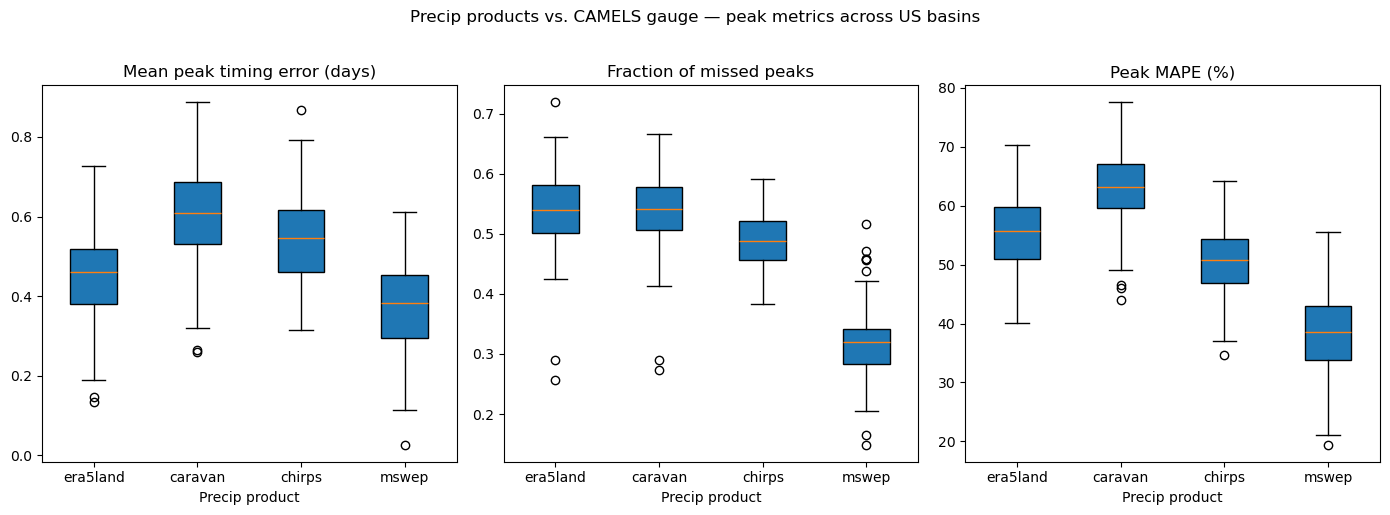

In [44]:
PRECIP_COLS_US = {
    "era5land": "era5land_total_precipitation",
    "caravan":     "total_precipitation_sum",
    "chirps":   "chirps_precipitation",
    "mswep":    "mswep_precipitation",
}
GAUGE_COL_US = "camels_precipitation"

results_us = []

for basin_name in basins:
    basin_id = basin_name.replace("camels_", "")

    try:
        ds = xr.open_dataset(time_series / f"{basin_name}.nc")
        ds = ds.drop_vars("basin")

        # Load CAMELS txt precipitation and add to ds
        file_path = next(camels_timeseries.rglob(f"*{basin_id}*.txt"))
        camels = pd.read_csv(file_path, sep="\s+", skiprows=3)
        camels["date"] = pd.to_datetime(camels[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}))
        camels_prcp = camels.set_index("date")["prcp(mm/day)"]

        camels_da = xr.DataArray(
            camels_prcp.values,
            coords={"date": camels_prcp.index.values},
            dims=["date"],
            name="camels_precipitation",
        )
        ds["camels_precipitation"] = camels_da.sel(date=ds.date)

        if GAUGE_COL_US not in ds:
            print(f"Skipping {basin_id}: no CAMELS gauge precip")
            continue

        obs: DataArray = ds[GAUGE_COL_US]

        for product_name, col in PRECIP_COLS_US.items():
            if col not in ds:
                print(f"  Skipping {product_name} for {basin_id}: column not found")
                continue

            sim: DataArray = ds[col]
            row = {"basin": basin_id, "product": product_name}

            try:
                row["peak_timing"] = mean_peak_timing(
                    obs, sim, resolution="1D", datetime_coord="date"
                )
            except Exception as e:
                row["peak_timing"] = np.nan
                print(f"  peak_timing failed ({basin_id}, {product_name}): {e}")

            try:
                row["missed_peaks"] = missed_peaks(
                    obs, sim, resolution="1D", datetime_coord="date"
                )
            except Exception as e:
                row["missed_peaks"] = np.nan
                print(f"  missed_peaks failed ({basin_id}, {product_name}): {e}")

            try:
                row["mape_peak"] = mean_absolute_percentage_peak_error(obs, sim)
            except Exception as e:
                row["mape_peak"] = np.nan
                print(f"  mape_peak failed ({basin_id}, {product_name}): {e}")

            results_us.append(row)

    except StopIteration:
        print(f"Skipping {basin_id}: CAMELS txt file not found")
    except Exception as e:
        print(f"Skipping {basin_id}: {e}")

# ── Summary ───────────────────────────────────────────────────────────────────
df_results_us = pd.DataFrame(results_us)

summary_us = (
    df_results_us
    .groupby("product")[["peak_timing", "missed_peaks", "mape_peak"]]
    .agg(["mean", "median", "std"])
    .round(3)
)
print(summary_us)

# ── Plot ──────────────────────────────────────────────────────────────────────
metrics = {
    "peak_timing":  "Mean peak timing error (days)",
    "missed_peaks": "Fraction of missed peaks",
    "mape_peak":    "Peak MAPE (%)",
}

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 5))

for ax, (metric, label) in zip(axes, metrics.items()):
    data = [
        df_results_us.loc[df_results_us["product"] == p, metric].dropna().values
        for p in PRECIP_COLS_US
    ]
    ax.boxplot(data, labels=list(PRECIP_COLS_US.keys()), patch_artist=True)
    ax.set_title(label)
    ax.set_xlabel("Precip product")

plt.suptitle("Precip products vs. CAMELS gauge — peak metrics across US basins", y=1.02)
plt.tight_layout()
plt.show()